In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/dogs-vs-cats/test1.zip
/kaggle/input/competitions/dogs-vs-cats/train.zip
/kaggle/input/competitions/dogs-vs-cats/sampleSubmission.csv


In [17]:
import os
import zipfile
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split

# 检查 GPU 是否可用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"可用 GPU 数量: {torch.cuda.device_count()}")

Using device: cuda
可用 GPU 数量: 2


In [18]:
# 解压训练集
with zipfile.ZipFile('/kaggle/input/competitions/dogs-vs-cats/train.zip', 'r') as zip_ref:
    zip_ref.extractall('/kaggle/working/')

# 查看一下解压后的文件数量
train_dir = '/kaggle/working/train'
filenames = os.listdir(train_dir)
print(f"Total images: {len(filenames)}") # 应该是 25000

data_list = []
for fname in filenames:
    if fname.split('.')[0] == 'dog' :
        label = 1 # dog 为 1
    else :
        label = 0 # cat 为 0
    data_list.append((os.path.join(train_dir, fname), label)) 
    # 将图片路径和标签组成一个元组，添加到 data_list 中，方便后续使用

# 拆分训练集和验证集 (80% 训练, 20% 验证)
train_data, val_data = train_test_split(data_list, test_size=0.2, random_state=42) 
# 使用 sklearn 的 train_test_split 函数随机拆分数据集，保证训练集和验证集的分布一致
# 其中 test_size=0.2 表示验证集占总数据的 20%，random_state=42 保证每次运行结果一致，方便调试和比较模型性能

print(f"Train size: {len(train_data)}, Val size: {len(val_data)}") 
# 输出训练集和验证集的大小，应该分别是 20000 和 5000

Total images: 25000
Train size: 20000, Val size: 5000


In [19]:
class CatDogDataset(Dataset): # 定义一个自定义数据集类，继承自 PyTorch 的 Dataset 类
    def __init__(self, data_list, transform=None):  # 初始化方法，接受数据列表和可选的图像变换
        self.data_list = data_list # 将数据列表保存为类的属性，方便后续使用
        self.transform = transform # 将图像变换保存为类的属性

    def __len__(self): # 定义返回数据集大小的方法，PyTorch 的 Dataset 类要求必须实现这个方法
        return len(self.data_list) # 返回数据列表的长度，即数据集的大小

    def __getitem__(self, idx): # 定义获取数据项的方法，PyTorch 的 Dataset 类也要求必须实现这个方法
        img_path, label = self.data_list[idx] # 根据索引 idx 从数据列表中获取图片路径和标签
        image = Image.open(img_path) # 读取图片
        
        if self.transform: # 如果定义了图像变换，则对图片进行变换
            image = self.transform(image) # 将 PIL 图片转换为 PyTorch 张量，并进行归一化等预处理操作
            
        return image, label  # 返回处理后的图片和对应的标签，供 DataLoader 使用

# 训练集：增加随机性
train_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 将图片缩放到 224x224，适合预训练模型的输入大小
    transforms.RandomHorizontalFlip(), # 随机水平翻转图片
    transforms.ToTensor(), # 将 PIL 图片转换为 PyTorch 张量，并将像素值归一化到 [0, 1] 范围
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
    # 使用 ImageNet 数据集的均值和标准差进行归一化，适合使用预训练模型的输入要求
])

# 验证集：只做缩放和归一化，不需要随机翻转
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 创建 DataLoader
train_dataset = CatDogDataset(train_data, transform=train_transform)
val_dataset = CatDogDataset(val_data, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [20]:
# 加载预训练模型
model = models.resnet18(pretrained=True) 
# 加载在 ImageNet 上预训练的 ResNet18 模型，预训练模型已经学习了丰富的特征，可以帮助我们更快地训练和获得更好的性能

# 冻结所有参数，不更新它们的梯度，只训练最后一层
# 我们只需要调整最后一层来适应新的分类任务（猫狗），而不需要重新训练整个模型，这样可以节省计算资源和时间，同时也能避免过拟合。
for param in model.parameters():
    param.requires_grad = False

# 修改最后一层：ResNet18 的 fc 层输入是 512，我们要把它改成输出 2 类
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) 

# 如果有多块 GPU (Accelerator T4 × 2) ，包装模型
if torch.cuda.device_count() > 1:
    print(f"检测到 {torch.cuda.device_count()} 块 GPU，开启多显卡模式！")
    model = nn.DataParallel(model)

model = model.to(device) # 把模型送入 GPU

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001) # 只优化最后一层

检测到 2 块 GPU，开启多显卡模式！


AttributeError: 'DataParallel' object has no attribute 'fc'

In [21]:
# 1. 加载并修改模型（此时 model 还是原始 ResNet）
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# 2. 定义优化器（在这里定义，直接用 model.fc，非常直观）
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# 3. 最后再包装多显卡
if torch.cuda.device_count() > 1:
    print(f"检测到 {torch.cuda.device_count()} 块 GPU，开启多显卡模式！")
    model = nn.DataParallel(model)

model = model.to(device)
criterion = nn.CrossEntropyLoss()

检测到 2 块 GPU，开启多显卡模式！


In [22]:
# 开始训练
epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()      # 梯度清零
        outputs = model(images)    # 前向传播
        loss = criterion(outputs, labels) # 计算损失
        loss.backward()            # 反向传播
        optimizer.step()           # 更新参数
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

print("Training Complete!")

Epoch 1/3, Loss: 0.1580
Epoch 2/3, Loss: 0.0806
Epoch 3/3, Loss: 0.0690
Training Complete!


In [23]:
def evaluate_model(model, dataloader, criterion):
    model.eval() # 切换到评估模式（关闭 Dropout 和 Batchnorm 的更新）
    running_loss = 0.0
    running_corrects = 0
    
    with torch.no_grad(): # 评估时不需要计算梯度，节省内存和计算量
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1) # 获取概率最高的类别序号
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
    val_loss = running_loss / len(dataloader.dataset)
    val_acc = running_corrects.double() / len(dataloader.dataset)
    
    print(f'Validation Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
    return val_loss, val_acc

# 执行验证
val_loss, val_acc = evaluate_model(model, val_loader, criterion)

Validation Loss: 0.0636 Acc: 0.9762


NameError: name 'train_losses' is not defined

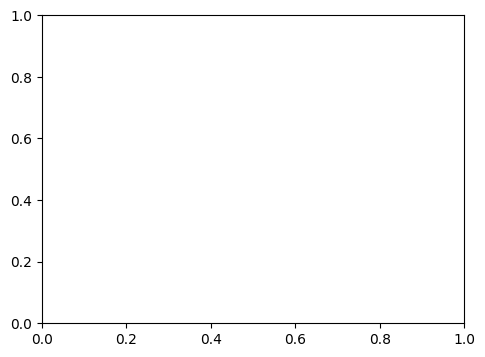

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

# 绘制 Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()

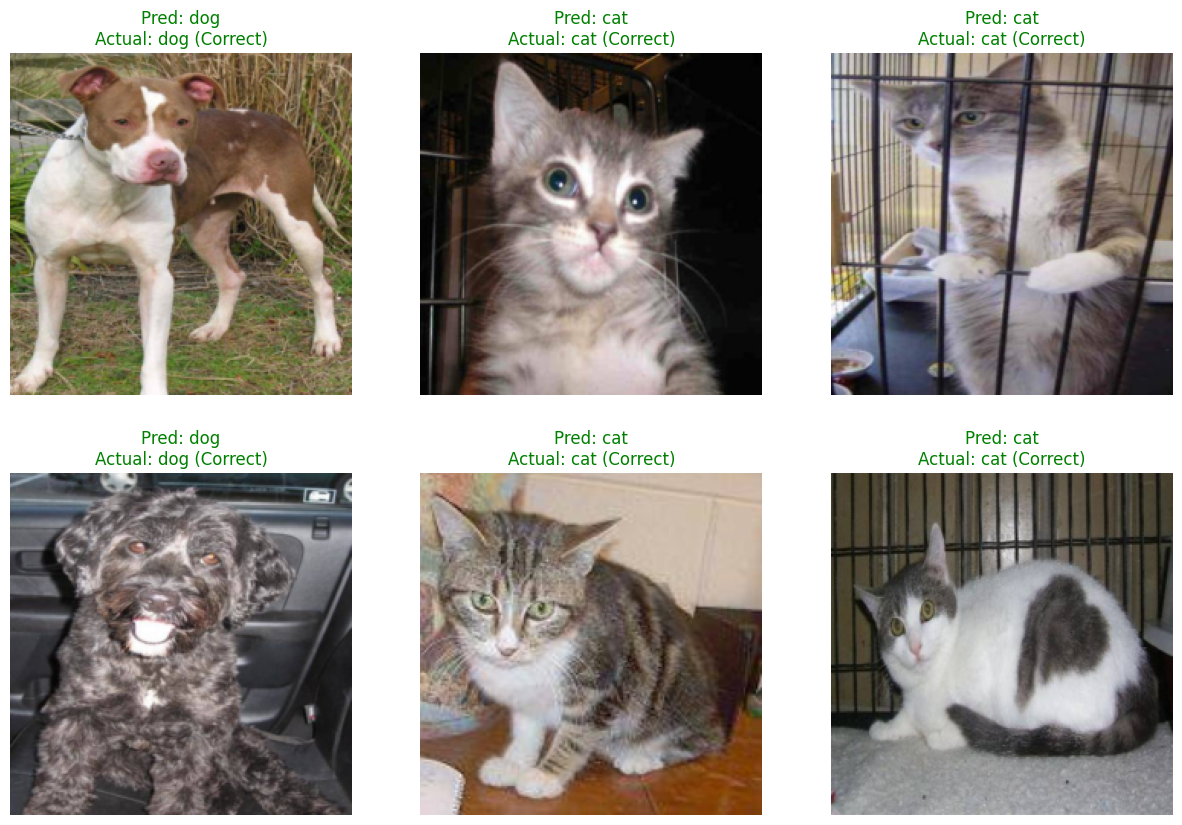

In [25]:
def visualize_predictions(model, dataloader, num_images=6):
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(15, 10))
    
    # 逆标准化 (把训练时的归一化还原回来，图片才能正常显示)
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 3, 3, images_so_far)
                ax.axis('off')
                
                # 还原图片并转回 HWC 格式供 plt 显示
                img = inv_normalize(inputs.data[j]).cpu().numpy().transpose((1, 2, 0))
                img = np.clip(img, 0, 1)
                
                is_correct = "Correct" if preds[j] == labels[j] else "Wrong"
                title_color = 'g' if preds[j] == labels[j] else 'r'
                ax.set_title(f'Pred: {"dog" if preds[j]==1 else "cat"}\nActual: {"dog" if labels[j]==1 else "cat"} ({is_correct})', color=title_color)
                plt.imshow(img)

                if images_so_far == num_images:
                    return

visualize_predictions(model, val_loader)

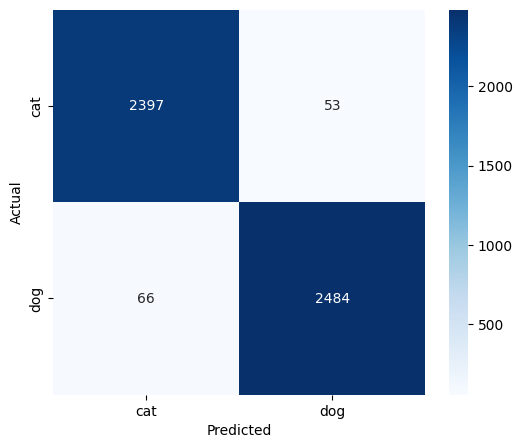

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['cat', 'dog'], yticklabels=['cat', 'dog'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()